In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")
df=pd.read_csv(r"C:\Users\User\Documents\Excel Projects\retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
df.dtypes

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

In [5]:
df['Date']=pd.to_datetime(df['Date'])
df.dtypes

Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

In [7]:
#Missing values
print(df.isnull().sum())

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [9]:
# Descriptive Stats
id_cols=["Transaction ID","Customer ID","Date"]
num_cols=["Age","Quantity","Price per Unit","Total Amount"]         
cat_cols=["Gender","Product Category"]
print(df[num_cols].describe().round(2))

           Age  Quantity  Price per Unit  Total Amount
count  1000.00   1000.00         1000.00        1000.0
mean     41.39      2.51          179.89         456.0
std      13.68      1.13          189.68         560.0
min      18.00      1.00           25.00          25.0
25%      29.00      1.00           30.00          60.0
50%      42.00      3.00           50.00         135.0
75%      53.00      4.00          300.00         900.0
max      64.00      4.00          500.00        2000.0


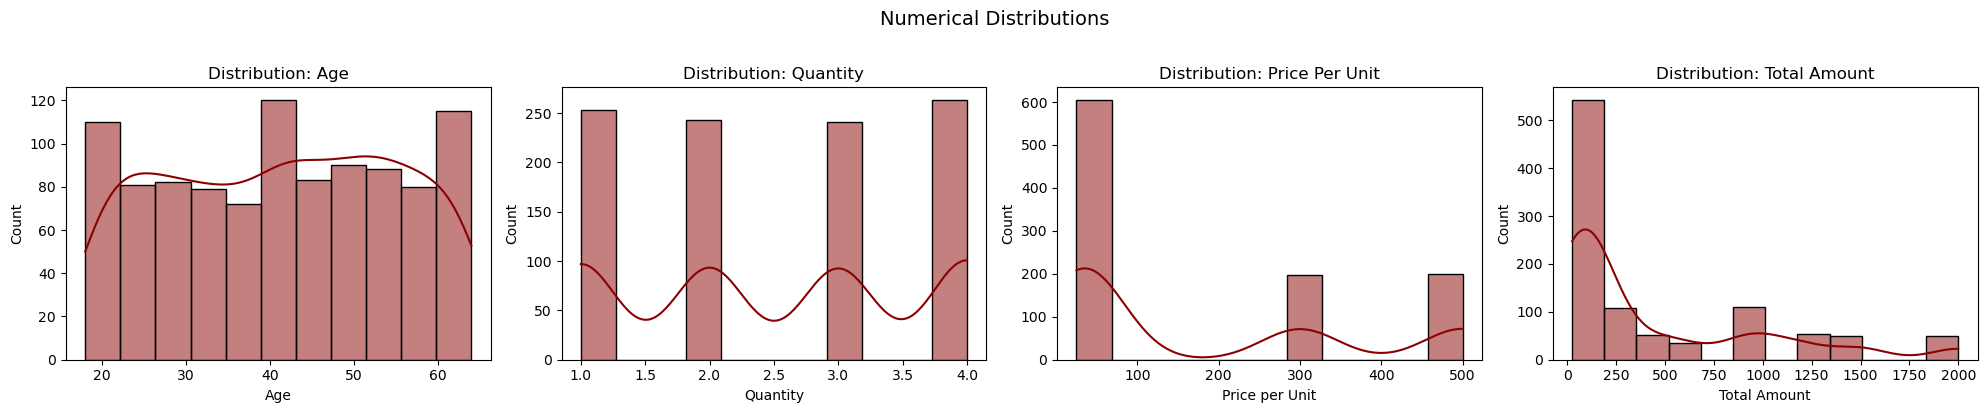

In [11]:
#Numerical Distributions
fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))
if len(num_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="darkred")
    ax.set_title(f"Distribution: {col.replace('_',' ').title()}")
plt.suptitle("Numerical Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

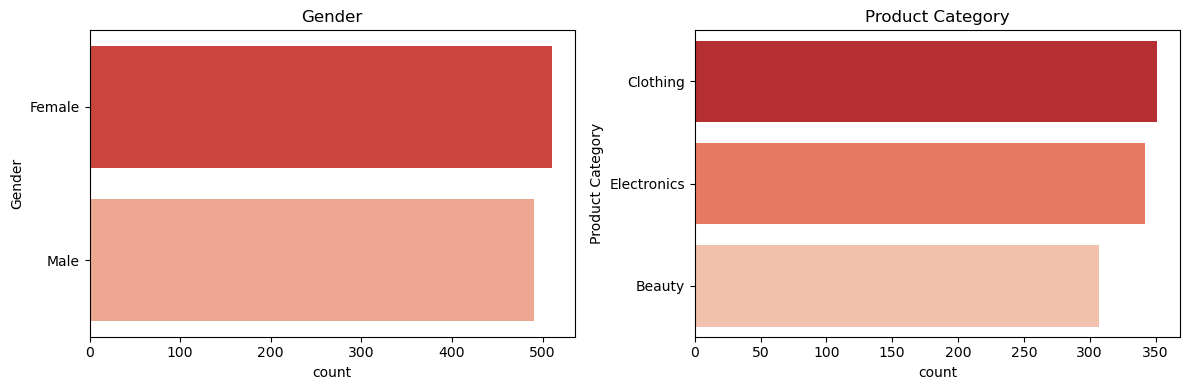

In [13]:
#Categorical Distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, y=col, order=df[col].value_counts().index,
                  palette="Reds_r", ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

Outliers in Age: 0 (0.0%)
Outliers in Quantity: 0 (0.0%)
Outliers in Price per Unit: 0 (0.0%)
Outliers in Total Amount: 0 (0.0%)


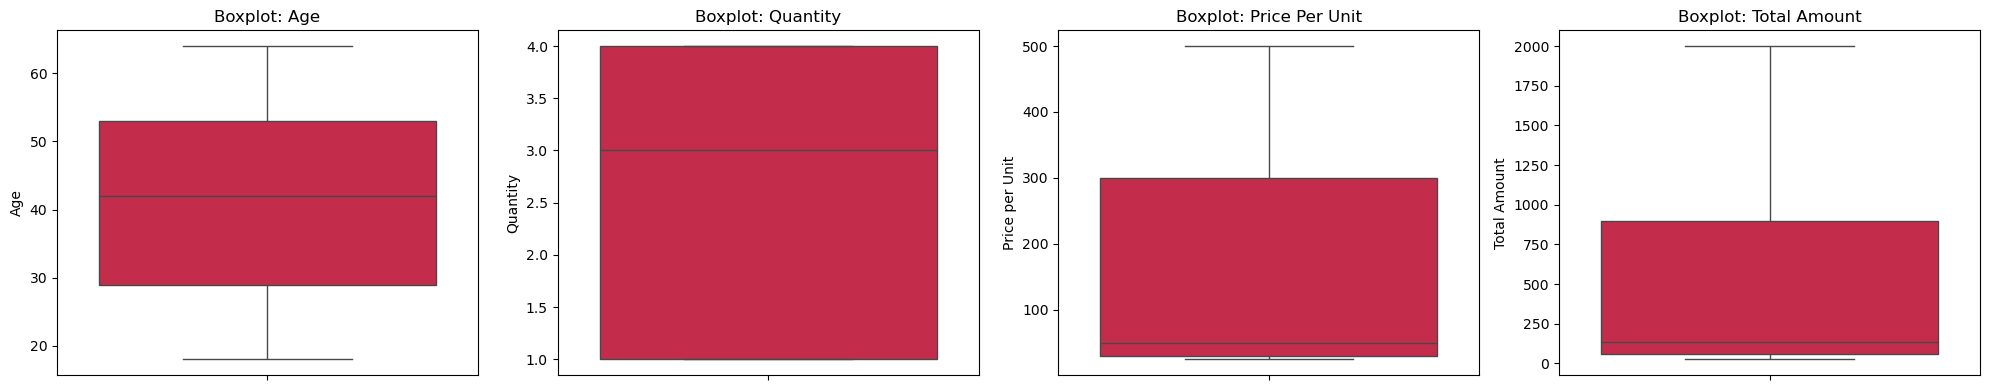

In [15]:
#Outlier detection
fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))
if len(num_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, num_cols):
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"Outliers in {col}: {n_out} ({n_out/len(df)*100:.1f}%)")
    sns.boxplot(y=df[col], ax=ax, color="crimson")
    ax.set_title(f"Boxplot: {col.replace('_',' ').title()}")
plt.tight_layout()
plt.show()

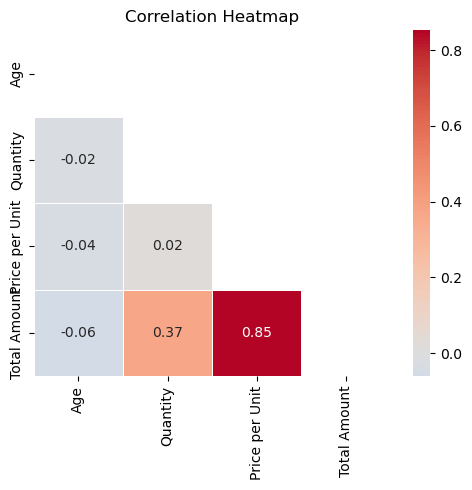

In [17]:
#Corelation Heatmap
if len(num_cols) >= 2:
    corr = df[num_cols].corr()
    fig, ax = plt.subplots(figsize=(5, 5))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, mask=np.triu(np.ones_like(corr, dtype=bool)),
                linewidths=0.5, ax=ax)
    ax.set_title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()

                  Total_Revenue  Avg_Order_Value  Transactions
Product Category                                              
Beauty                   143515           467.48           307
Clothing                 155580           443.25           351
Electronics              156905           458.79           342


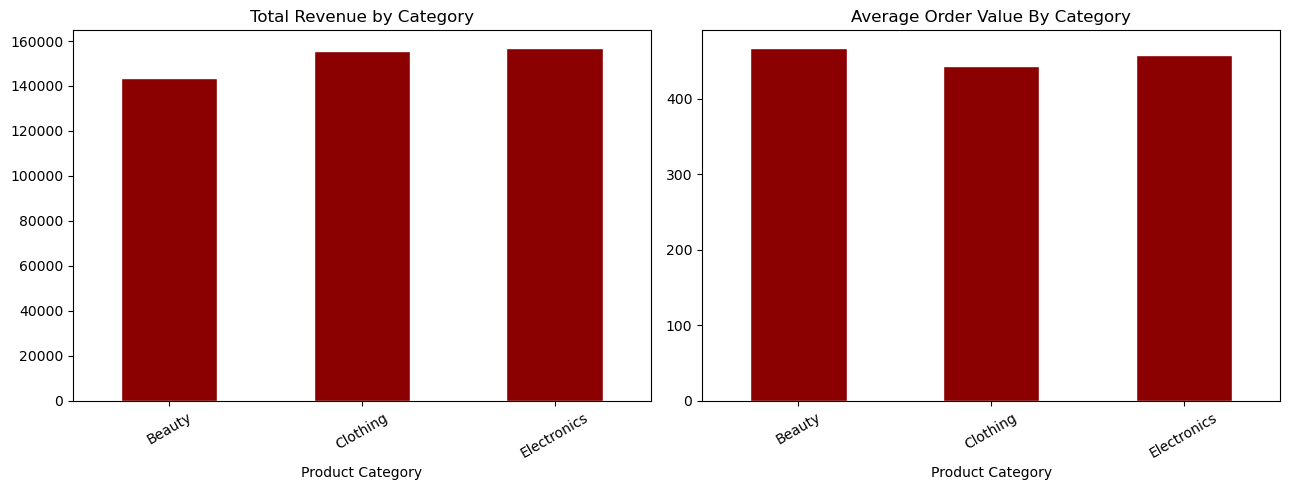

In [19]:
#Revenue by Category
cat_rev=df.groupby("Product Category")["Total Amount"].agg(Total_Revenue="sum",Avg_Order_Value="mean",Transactions="count")
print(cat_rev.round(2))
fig, axes=plt.subplots(1,2,figsize=(13,5))
cat_rev["Total_Revenue"].plot(kind="bar", ax=axes[0], color="darkred", edgecolor="white")
axes[0].set_title("Total Revenue by Category")
axes[0].tick_params(axis="x", rotation=30)
cat_rev["Avg_Order_Value"].plot(kind="bar",ax=axes[1],color="darkred",edgecolor="white")
axes[1].set_title("Average Order Value By Category")
axes[1].tick_params(axis="x",rotation=30)
plt.tight_layout()
plt.show()

        Total_Revenue  Avg_Spend  Transactions
Gender                                        
Female         232840     456.55           510
Male           223160     455.43           490


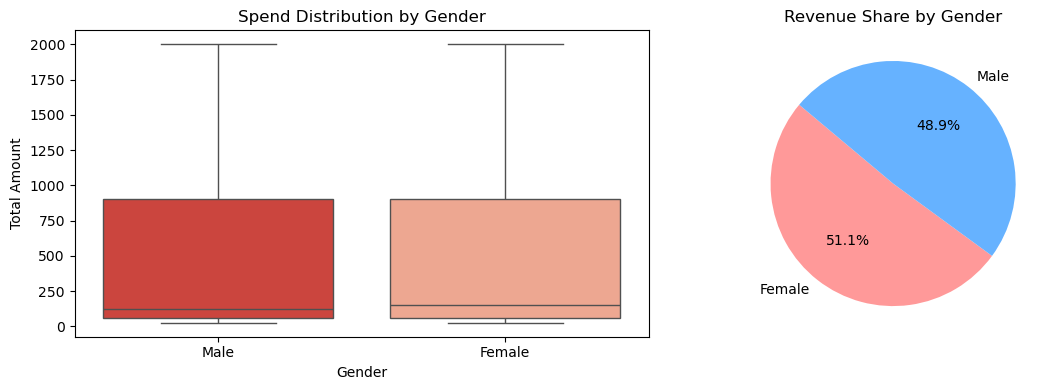

In [21]:
#Gender by category
gender_rev=df.groupby("Gender")["Total Amount"].agg(Total_Revenue="sum",Avg_Spend="mean",Transactions="count").round(2)
print(gender_rev)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="Gender", y="Total Amount", palette="Reds_r", ax=axes[0])
axes[0].set_title("Spend Distribution by Gender")
gender_rev["Total_Revenue"].plot(kind="pie", ax=axes[1], autopct="%1.1f%%",colors=["#FF9999", "#66B2FF"], startangle=140)
axes[1].set_title("Revenue Share by Gender")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

           Total_Revenue  Avg_Spend
Age Group                          
18-24             501.01     501.01
24-34             478.28     478.28
35-44             467.80     467.80
45-59             437.45     437.45
60+               389.70     389.70


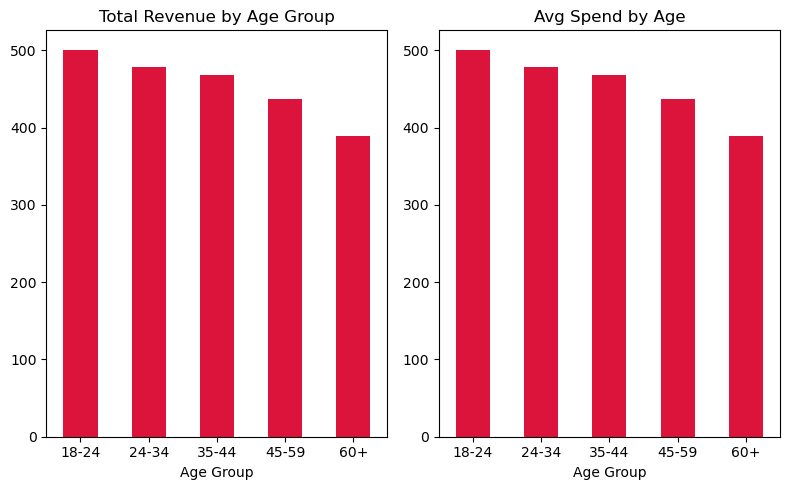

In [23]:
#Age group analysis
bins=[18,25,35,45,60,100]
labels=["18-24","24-34","35-44","45-59","60+"]
df['Age Group']=pd.cut(df['Age'],bins=bins,labels=labels,right=False)
age_rev=df.groupby('Age Group')['Total Amount'].agg(Total_Revenue="mean",Avg_Spend="mean").round(2)
print(age_rev)
fig,axes=plt.subplots(1,2,figsize=(8,5))
age_rev["Total_Revenue"].plot(kind="bar",ax=axes[0],color='crimson')
axes[0].set_title("Total Revenue by Age Group")
axes[0].tick_params(axis="x",rotation=0)
age_rev["Avg_Spend"].plot(kind="bar", ax=axes[1], color='crimson')
axes[1].set_title("Avg Spend by Age")
axes[1].tick_params(axis="x",rotation=0)
plt.tight_layout()
plt.show()

      Month  Total_Rev  Avg_Rev
0   2023-01      35450   466.45
1   2023-02      44060   518.35
2   2023-03      28990   397.12
3   2023-04      33870   393.84
4   2023-05      53150   506.19
5   2023-06      36715   476.82
6   2023-07      35465   492.57
7   2023-08      36960   393.19
8   2023-09      23620   363.38
9   2023-10      46580   485.21
10  2023-11      34920   447.69
11  2023-12      44690   491.10
12  2024-01       1530   765.00


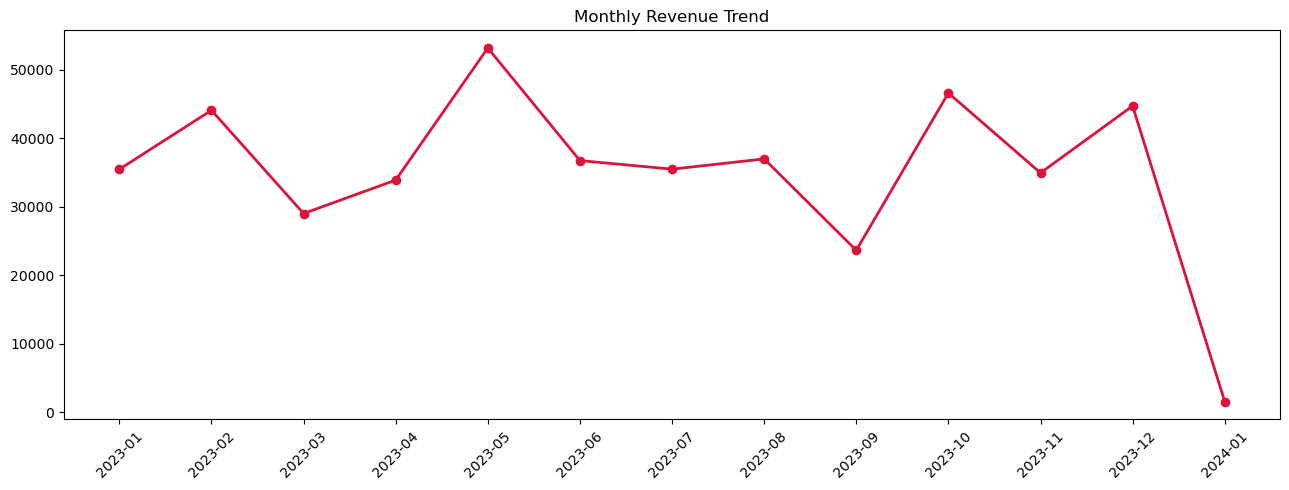

In [25]:
#Monthly Revenue Trend
df['Month']=df['Date'].dt.to_period("M")
monthly=df.groupby('Month')['Total Amount'].agg(Total_Rev="sum",Avg_Rev="mean").round(2).reset_index()
monthly['Month']=monthly['Month'].astype(str)
print(monthly)
fig, ax=plt.subplots(figsize=(13,5))
ax.plot(monthly.index,monthly["Total_Rev"],marker="o",color='crimson',lw=2)
ax.set_title("Monthly Revenue Trend")
ax.set_xticks(monthly.index)
ax.set_xticklabels(monthly['Month'],rotation=45)
plt.tight_layout()
plt.show()

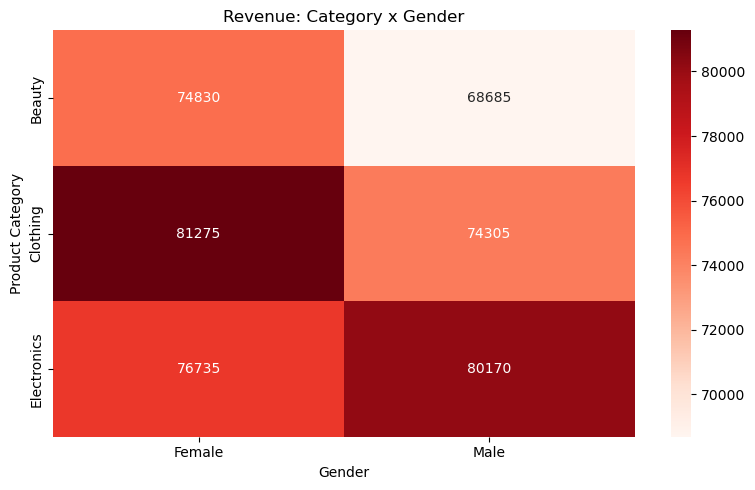

In [27]:
#Category -Gender Heatmap
pivot=df.pivot_table(values="Total Amount", index="Product Category",columns="Gender",aggfunc="sum")
fig, axes=plt.subplots(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt=".0f",cmap= "Reds")
axes.set_title("Revenue: Category x Gender")
plt.tight_layout()
plt.show()

In [29]:
#Shapiro Wilk Normality Test
alpha=0.05
sample=df['Total Amount'].sample(min(5000,len(df)),random_state=42)
stat,p=stats.shapiro(sample)
print(f"Statistic={stat:.4f}, p-value={p:.4f}")
print("Normal?", "No, use non-parametric tests" if p< alpha else "Yes, use parametric tests")

Statistic=0.7489, p-value=0.0000
Normal? No, use non-parametric tests


In [33]:
#Mann-Whitney U Test Gender vs Total Amount
male=df[df["Gender"]=="Male"]["Total Amount"]
female=df[df["Gender"]=="Female"]["Total Amount"]
stat,p=stats.mannwhitneyu(male, female, alternative="two-sided")
print(f"Statistic={stat:.2f},p-value={p:.4f}")
print("significant?", "Yes" if p < alpha else "No")

Statistic=123636.50,p-value=0.7731
significant? No


In [35]:
#Chi-Square Test Gender vs Category
ct=pd.crosstab(df["Gender"],df["Product Category"])
chi2, p,dof,expected=stats.chi2_contingency(ct)
print(f"Chi2={chi2:.2f},df={dof},p-value={p:.4f}")
print("Significant?","Yes" if p<alpha else"No")
print(ct)

Chi2=1.67,df=2,p-value=0.4330
Significant? No
Product Category  Beauty  Clothing  Electronics
Gender                                         
Female               166       174          170
Male                 141       177          172


In [41]:
#Kruskal-Wallis Category vs spend
groups = [grp["Total Amount"].values for _, grp in df.groupby("Product Category")]
stat, p = stats.kruskal(*groups)
print(f"Statistic = {stat:.2f}, p-value = {p:.4f}")
print("Significant?", "Yes" if p < alpha else "No")

Statistic = 0.06, p-value = 0.9727
Significant? No


In [39]:
#Spearmann Correlation Age vs Spend
r,p=stats.spearmanr(df["Age"],df["Total Amount"])
print(f"Spearman r={r:.4f}, p-value={p:.4f}")
print("Significant?", "Yes" if p< alpha else "No")

Spearman r=-0.0379, p-value=0.2316
Significant? No


In [67]:
print("Transactions:", len(df))
print("Unique Customers:", df["Customer ID"].nunique())

Transactions: 1000
Unique Customers: 1000
